In [6]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack
import fitsio
# from astropy.io import fits

from astropy.coordinates import SkyCoord
from astropy import units as u

In [3]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [19]:
data_dir = '/Users/rongpu/Documents/Data/desi_targets/dr8.0/0.42.0/ra_dec_only'
fns = ['dr8_BGS_BRIGHT_ra_dec_only.fits', 'dr8_BGS_FAINT_ra_dec_only.fits', 'dr8_BGS_BRIGHT_AND_FAINT_ra_dec_only.fits', 'dr8_ELG_ra_dec_only.fits', 'dr8_LRG_ra_dec_only.fits', 'dr8_QSO_ra_dec_only.fits']

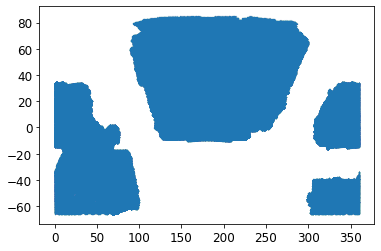

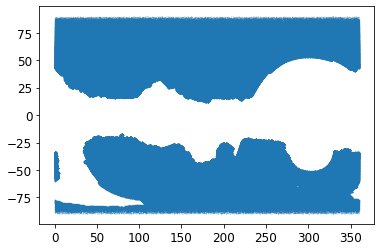

In [11]:
fn = 'dr8_QSO_ra_dec_only.fits'

cat = Table(fitsio.read(os.path.join(data_dir, fn), columns=['RA', 'DEC']))
tmp = SkyCoord(ra=cat['RA']*u.degree, dec=cat['DEC']*u.degree, frame='icrs').galactic
l, b = np.array(tmp.l), np.array(tmp.b)
cat['l'] = l
cat['b'] = b

plt.plot(cat['RA'], cat['DEC'], '.', ms=0.1)
plt.show()

plt.plot(cat['l'], cat['b'], '.', ms=0.1)
plt.show()

In [20]:
for fn in fns:
    print(fn)
    cat = Table(fitsio.read(os.path.join(data_dir, fn), columns=['RA', 'DEC']))
    mask = cat['DEC']>-30
    cat = cat[mask]
    tmp = SkyCoord(ra=cat['RA']*u.degree, dec=cat['DEC']*u.degree, frame='icrs').galactic
    l, b = np.array(tmp.l), np.array(tmp.b)
    cat['l'] = l.astype('float32')
    cat['b'] = b.astype('float32')
    cat = cat[['l', 'b']]
    cat.write(os.path.join(data_dir, fn).replace('ra_dec_only.fits', 'l_b_only_dec_above_minus_30.fits'))

dr8_BGS_BRIGHT_ra_dec_only.fits
dr8_BGS_FAINT_ra_dec_only.fits
dr8_ELG_ra_dec_only.fits
dr8_LRG_ra_dec_only.fits
dr8_QSO_ra_dec_only.fits
